In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
 
import math
import numpy as np
import random

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.transforms as transforms
from torchvision.models import efficientnet_b0
from PIL import Image
from tqdm.notebook import tqdm
from syn2real_dataset import Syn2RealDataset
from string_to_xml_to_vec import string2vec, vec2string, vec2xml, pretty_print_xml
import numpy as np
import math
import os

# Add ../ as a directory to import from
import sys
sys.path.append('../')

In [2]:
from models.plightning import  MainDataModule

dataset_dir = "../data/Sideview_Dec23_2024"
datamodule = MainDataModule(dataset_dir,
                            image_size=224,
                            load_depth=False,
                            train_batch_size=32, num_workers=1, process_leaf=True, preload=False, side_view=True)
datamodule.setup()

Total 1000 images and plant strings loaded
Total 500 images and plant strings loaded
Total 500 images and plant strings loaded


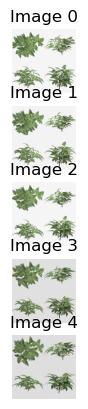

In [3]:
# Show some images
import matplotlib.pyplot as plt
import numpy as np
import torchvision
import cv2


test_dataloader = datamodule.test_dataloader()
test_dataset = test_dataloader.dataset

n = 5
for i in range(n):
    image, _, vecs, _ = test_dataset[-i-1]
    image = image.permute(1, 2, 0)
    image_rgb = image[:, :, :3]
    img = cv2.normalize(np.array(image_rgb.cpu()), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(5, 2, 2*i+1)
    plt.imshow(img)
    plt.title(f"Image {i}")
    plt.axis('off')

    if datamodule.load_depth:
        image_depth = image[:, :, 3]
        img = cv2.normalize(np.array(image_depth.cpu()), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
        plt.subplot(5, 2, 2*i+2)
        plt.imshow(img, cmap='gray')
        plt.title("Depth")
        plt.axis('off')

In [4]:
from models.plightning import MainModule
# model = MainModule()
model = MainModule.load_from_checkpoint("../log/20250109_SideView_448_MinMaxScaler/version_2/checkpoints/last.ckpt")

model.eval()
# model.freeze()

MainModule(
  (depth_est_model): DepthAnythingForDepthEstimation(
    (backbone): Dinov2Backbone(
      (embeddings): Dinov2Embeddings(
        (patch_embeddings): Dinov2PatchEmbeddings(
          (projection): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (encoder): Dinov2Encoder(
        (layer): ModuleList(
          (0-11): 12 x Dinov2Layer(
            (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
            (attention): Dinov2Attention(
              (attention): Dinov2SelfAttention(
                (query): Linear(in_features=384, out_features=384, bias=True)
                (key): Linear(in_features=384, out_features=384, bias=True)
                (value): Linear(in_features=384, out_features=384, bias=True)
                (dropout): Dropout(p=0.0, inplace=False)
              )
              (output): Dinov2SelfOutput(
                (dense): Linear(in_features=384, out_featur

Total 100 images and plant strings loaded
Total 50 images and plant strings loaded
Total 50 images and plant strings loaded
Total 1000 images and plant strings loaded
Total 500 images and plant strings loaded
Total 500 images and plant strings loaded


/tmp/ipykernel_3401894/3727797754.py:90: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  out = torch.tensor(out).to(device)


KeyboardInterrupt: 

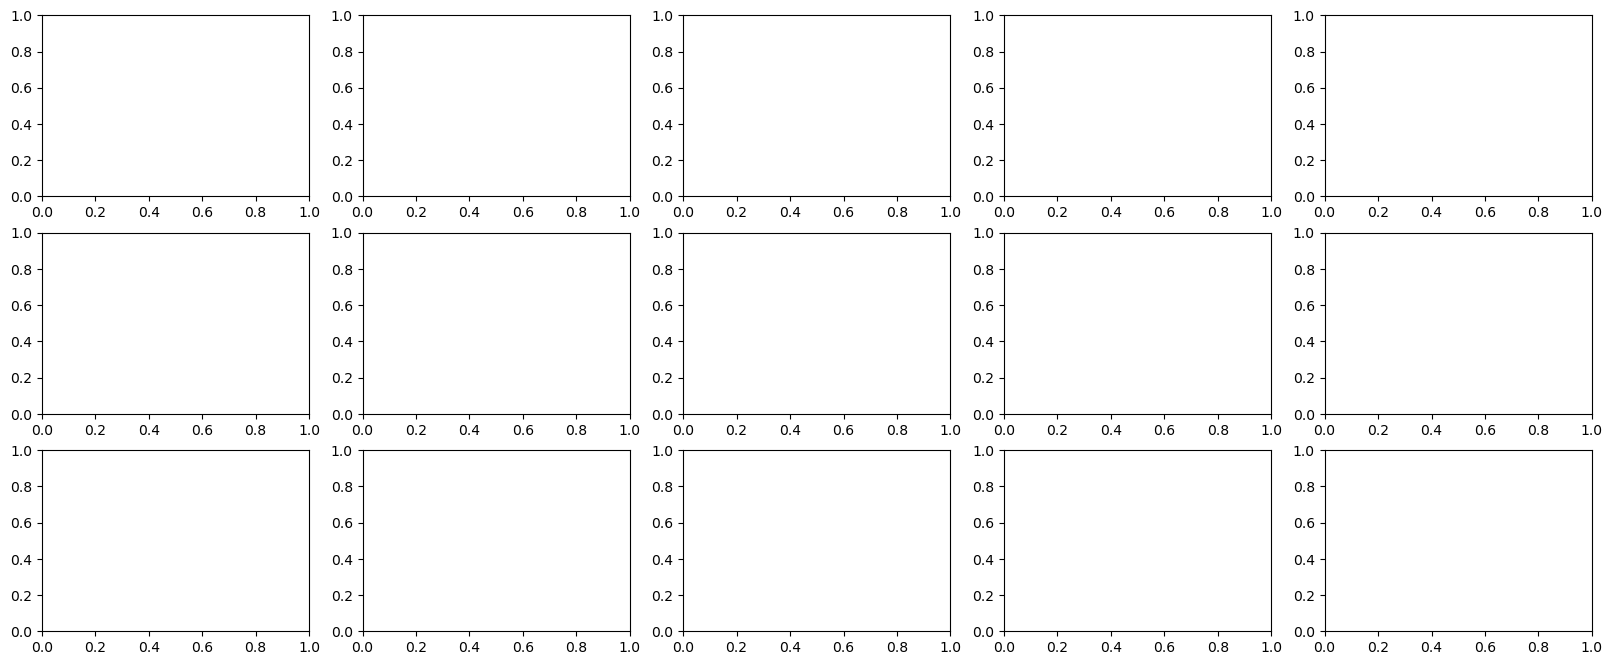

In [6]:
import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from plant_tokenizer import SOS_vec_padded, SOS_token, EOS_token
from models.model import get_tgt_mask
from plant_dataset import PlantDataset, load_sideview_images
from image_process import process_leaf_image
from plantstring2model import plantstring2model
from string_to_xml_to_vec import vec2xml, recursive_to_linked
from plant_tokenizer import token2vec
import subprocess
import shutil
from models.plightning import MainDataModule

import joblib

param_scaler = joblib.load("scaler.pkl")
if 0:
    transform = transforms.Compose([
        # transforms.ToTensor(),
    ])
    stages = [f"{date:02d}" for date in range(0,19)]
    test_dataset = PlantDataset("../data/2000_Plots_20241210", image_size=224, transform=transform, stages=stages,
                                load_depth=False, process_leaf=False, preload=False)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=MainDataModule.collate_fn)
else:
    from models.plightning import MainDataModule
    #dataset_dir = "../data/generated_Nov22_2024"
    #dataset_dir = "../data/2000_Plots_20241210"
    dataset_dir = "../data/Sideview_Dec23_2024"
    #dataset_dir = "../data/generated_Dec10_2024"
    datamodule = MainDataModule(dataset_dir,
                                image_size=model.image_size,
                                load_depth=False,
                                train_batch_size=1, num_workers=0, process_leaf=True, preload=False, side_view=True)
    growth_stages = [f"{day:02d}" for day in range(0,2)]
    datamodule.setup(growth_stages=growth_stages)
    datamodule.setup()
    if 1:
        dataloader = datamodule.test_dataloader()
        #dataloader = datamodule.val_dataloader()
    else:
        dataloader = datamodule.train_dataloader()

program_path = "../src/GenerateDataset/build"

# Function to re-render a single XML file
def re_render_xml(output_path, filename, rotation=True):
    image_name = filename.split("/")[-1].split(".")[0]
    os.environ["DISPLAY"] = ":12.0"
    #os.environ["DISPLAY"] = ":1.0"
    # Generate image 
    # Construct the command
    command = ""
    command += f"cd {program_path} && ./main " 
    command += f"-h 1.0 -o {output_path} -name {image_name} -tile none -f {os.path.join(output_path, filename)}"
    if rotation:
        command += " -r"
    result = subprocess.run(command, shell=True, capture_output=True, text=True)
    print(result.stdout)
    print(result.stderr)
    return result

# Prepare the figure
n_figures = 5
fig, axes = plt.subplots(3, n_figures, figsize=(20, 8))

# Create temp folder
temp_folder = "temp"
shutil.rmtree(temp_folder, ignore_errors=True)
os.makedirs(temp_folder, exist_ok=True)

image_size = model.image_size
# Process and display 10 images
model.eval()
device = model.device
for idx, (image, plant_info, out, lengths) in enumerate(dataloader):
    if idx >= n_figures:
        break
    
    # print(dataloader.dataset.plant_xml_files[idx])
    if image.dim() == 3:
        image = image.unsqueeze(0)

    image = image.to(device)
    plant_info = plant_info.to(device)

    out = torch.tensor(out).to(device)
    ground_truth = out.squeeze(0).cpu().numpy()

    plant_vec = token2vec(ground_truth)
    plant_xml = vec2xml(plant_vec, debug=True)
    plant_xml_file_name = f"temp/plant_{idx}_gt.xml"
    plant_xml_str = pretty_print_xml(plant_xml)
    with open(plant_xml_file_name, "w") as f:
        f.write(plant_xml_str)
    plant_xml = recursive_to_linked(plant_xml)

    plant_xml_str = pretty_print_xml(plant_xml)
    with open(plant_xml_file_name, "w") as f:
        f.write(plant_xml_str)

    if 0:
        re_render_xml(os.path.abspath(temp_folder), os.path.abspath(plant_xml_file_name))
        img = cv2.imread(plant_xml_file_name.replace("xml","jpeg"))
        if 0:
            leaf_area, plant_width, plant_height, leaf_img, _ = process_leaf_image(img, sqaure_crop=True, thr=0.2)
            img = cv2.resize(leaf_img, (image_size, image_size))
        else:
            img = cv2.resize(img, (image_size, image_size))
        gt_img = img.copy()
    
    ############## Generate

    with torch.no_grad():
        result = model.generate(image, plant_info)
        result = result.cpu().numpy()


    plant_vec = token2vec(result)
    plant_xml = vec2xml(plant_vec, debug=True)
    plant_xml_file_name = f"temp/plant_{idx}.xml"
    plant_xml_str = pretty_print_xml(plant_xml)
    with open(plant_xml_file_name, "w") as f:
        f.write(plant_xml_str)
    plant_xml = recursive_to_linked(plant_xml)

    plant_xml_str = pretty_print_xml(plant_xml)
    with open(plant_xml_file_name, "w") as f:
        f.write(plant_xml_str)

    re_render_xml(os.path.abspath(temp_folder), os.path.abspath(plant_xml_file_name))

    img, _ = load_sideview_images(temp_folder, plant_xml_file_name.replace("xml","jpeg"), model.image_size, True)

        
    image_vis = image[0].permute(1, 2, 0).cpu()

    image_vis = cv2.normalize(np.array(image_vis), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    row, col = divmod(idx, n_figures)
    axes[row, col].imshow(image_vis[:, :, 0:3])
    axes[row, col].set_title(f"Input Image {idx + 1}")
    axes[row, col].axis('off')

    # axes[row+1, col].imshow(gt_img[:, :, 0:3])
    # axes[row+1, col].set_title(f"Re-Renderd Image {idx + 1}")
    # axes[row+1, col].axis('off')

    # depth = model.predicted_depth.squeeze().cpu()
    # axes[row+1, col].imshow(depth)
    # axes[row+1, col].set_title(f"Estimated Depth Image {idx + 1}")
    # axes[row+1, col].axis('off')

    axes[row + 2, col].imshow(img)
    axes[row + 2, col].set_title(f"Output Model {idx + 1}")
    axes[row + 2, col].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Draw a 14x14 grid on the image_vis[:,:,0:3]
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image_vis[:,:,0:3])
axes[0].set_title("Input Image")
axes[0].axis('off')

for i in range(1, 14):
    axes[0].axvline(i*16, color='r', linestyle='--')
    axes[0].axhline(i*16, color='r', linestyle='--')
    axes[1].axvline(i*16, color='r', linestyle='--')
    axes[1].axhline(i*16, color='r', linestyle='--')
plt.show()

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import cv2

from utils import visualize_attention
from string_to_xml_to_vec import plant_string2words
from plant_tokenizer import token2vec

# Visualize attention
# Example words
plant_vec = token2vec(result)
plant_xml = vec2string([plant_vec])

words = plant_string2words(plant_xml)
print(words)

if 0:
    # Add <SOS> to the beginning of the list of words
    words = ["<SOS>"] + words
else:
    # Add <EOS> to the end of the list of words
    words = words + ["<EOS>"]

def shorten_title(title, max_length=10):
    """Shorten the title if it is too long."""
    if "foliate" in title:
        title = "Shoot"
    elif "Internode" in title:
        title = "Internode"
    elif "Petiole" in title:
        title = "Petiole"
    elif "Leaf" in title:
        title = "Leaf"
    return title

# Create a word_dimx3 subplot
multihead_attn_weights = model.sequence_decoder.multihead_attn_weights
image_dict = {}
num_cols = 10  # Number of images per row

for layer_index in range(len(multihead_attn_weights)):
    num_rows = (len(words) + num_cols - 1) // num_cols  # Calculate the number of rows needed
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 2, num_rows * 2))
    fig.suptitle(f'Layer {layer_index + 1}', fontsize=16)
    
    for word_index in range(len(words)):
        row = word_index // num_cols
        col = word_index % num_cols
        overlay = visualize_attention(image_vis, multihead_attn_weights, words, word_index, layer_index, interpolation=cv2.INTER_NEAREST)
        image_dict[(layer_index, word_index)] = overlay
        axes[row][col].imshow(overlay)
        axes[row][col].axis('off')
        short_title = shorten_title(words[word_index])
        axes[row][col].set_title(f"{word_index}:{short_title}", rotation=0, ha='right', fontsize=8)
    
    # Hide any unused subplots
    for i in range(len(words), num_rows * num_cols):
        row = i // num_cols
        col = i % num_cols
        axes[row][col].axis('off')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9, wspace=0.3, hspace=0.3)  # Adjust the top to make room for the suptitle and add space between subplots
    plt.show()

In [ ]:
# Create a output folder
output_dir = "attention_output"
# Remove the folder if it exists
if os.path.exists(output_dir):
    import shutil
    shutil.rmtree(output_dir)
if not os.path.exists(output_dir):
    os.makedirs(output_dir)



# Save the attention images
for key, img in image_dict.items():
    layer_index, word_index = key
    img_vis = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    file_name = f"layer_{layer_index}_word_{word_index}_{words[word_index]}.png"
    file_path = os.path.join(output_dir, file_name)
    cv2.imwrite(file_path, img_vis)